# Looping Graph
---
- Implement `Looping Logic` to route the flow of the data back to the nodes
- Create a single `Conditional Edge` to handle decision-making and contro; graph flow.

### Main Goal:
- Coding up `Looping Logic`

In [24]:
# Imports
import random
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from tools.VGraph import Helper

In [25]:
# Helping Tools
__tools__ = Helper()

In [26]:
# Schema
class Agent6(TypedDict):
    name: str
    values: List[int]
    counter: int

In [27]:
# Nodes
def f1_node(state: Agent6) -> Agent6:
    """The first node, welcome to the user"""
    state["name"] = f"Hi {state['name']}! Generating random numbers"
    state["counter"] = 0
    return state

def f2_random_node(state: Agent6) -> Agent6:
    """Generate random number from 0-10"""
    state["values"].append(random.randint(0,10))
    state["counter"] += 1
    return state

def looper(state: Agent6) -> Agent6:
    """Func for seleting looping or ending"""
    if state["counter"] < 5:
        print(f'Entering Loop : {state["counter"]}')
        return "loop"
    else:
        return "exit"

In [28]:
# Create Graph
graph = StateGraph(Agent6)

graph.add_node("func1", f1_node)
graph.add_node("func2", f2_random_node)
graph.add_edge(START, "func1")
graph.add_edge("func1", "func2")

graph.add_conditional_edges(
    source="func2",
    path=looper,
    path_map={
        "loop": "func2",
        "exit": END
    }
)

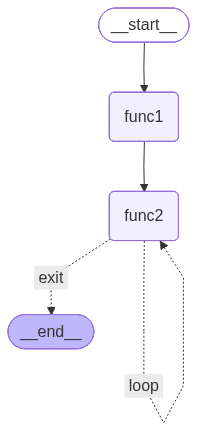

In [29]:
# Create App
app = graph.compile()

# View Graph
__tools__.view_graph(app)

In [30]:
# Checker
res = app.invoke(
    {
        "name": "Rakib",
        "values": [],
        "counter": 10
    }
)

__tools__.monitor({"Final Result": res})

Entering Loop : 1
Entering Loop : 2
Entering Loop : 3
Entering Loop : 4
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
{
    "Final Result": {
        "name": "Hi Rakib! Generating random numbers",
        "values": [
            8,
            5,
            6,
            9,
            9
        ],
        "counter": 5
    }
}
####################################################################################################
